<a href="https://colab.research.google.com/drive/1y0TvfvGXgWuCpZayCzijRr0GQpgI_XS0?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification

<center>
  <img src="https://www.jcchouinard.com/wp-content/uploads/2021/11/image-1-1024x929.png"><br>
  ภาพจาก: <a href="https://www.jcchouinard.com/decision-trees-in-machine-learning/">Decision Trees in Machine Learning, with Examples (Python)</a>
</center>

**ต้นไม้การตัดสินใจ (Decision Tree)**
1. **ความหมาย**: เทคนิคการเรียนแบบ Supervised Learning ที่ใช้ Tree เป็นโมเดลการทำนายค่าเป้าหมาย (Target Value) จากข้อมูล
2. **โครงสร้าง**:
   - Node: แทนคุณสมบัติ (Feature) ของข้อมูล
   - Branch: แทนการตัดสินใจ (Decision)
   - Leaf: แทนผลลัพธ์ (Outcome)
3. **การทำงาน**: เริ่มจาก Root Node และตามสาขาที่ตรงกับคุณสมบัติของข้อมูลจนถึง Leaf Node
4. **ข้อดี**: เข้าใจง่ายและไม่ต้องการการเตรียมข้อมูลมากนัก
5. **ข้อเสีย**: มักจะมีประสิทธิภาพต่ำเมื่อมีข้อมูลที่ซับซ้อน

## 1.1 แหล่งข้อมูล Iris Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
iris_df = pd.read_csv('/content/drive/MyDrive/ML dataset/iris.csv')
iris_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## 1.2 แบ่ง Train / Test Dataset

* ใช้ train_test_split จาก library sklearn.model_selection
```python
from sklearn.model_selection import train_test_split
```
* เรียกใช้ train_test_split
```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=?)
```

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_df.iloc[:,:4], iris_df['variety'], test_size=0.2, random_state=888)

## 1.3 สร้าง Decision Tree

* import library เพื่อสร้าง tree
```
from sklearn.tree import DecisionTreeClassifier
```

In [ ]:
from sklearn.tree import DecisionTreeClassifier

* สร้าง Tree เปล่า
```
DecisionTreeClassifier()
```
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [ ]:
iris_cf = DecisionTreeClassifier(criterion='gini' ,random_state=601) # หรือ 'entropy'

* เรียนรู้ข้อมูล
```
fit(X, y)
```

In [ ]:
iris_cf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=601)

## 1.4 ดูโมเดล Decision Tree ที่ได้

### 1.4.1 แบบ Text

* import library เพื่อแสดง tree
```
from sklearn.tree import export_text
```

In [ ]:
from sklearn.tree import export_text

* แสดง Text Tree

In [ ]:
print(export_text(iris_cf, feature_names=X_train.columns.tolist()))
# X_train.columns เป็น Pandas Index object แต่ export_text(decision_tree, feature_names=...) ต้องการ argument ที่เป็น list ของชื่อ feature

|--- petal.length <= 2.45
|   |--- class: Setosa
|--- petal.length >  2.45
|   |--- petal.width <= 1.65
|   |   |--- petal.length <= 4.95
|   |   |   |--- class: Versicolor
|   |   |--- petal.length >  4.95
|   |   |   |--- class: Virginica
|   |--- petal.width >  1.65
|   |   |--- petal.length <= 4.85
|   |   |   |--- sepal.width <= 3.10
|   |   |   |   |--- class: Virginica
|   |   |   |--- sepal.width >  3.10
|   |   |   |   |--- class: Versicolor
|   |   |--- petal.length >  4.85
|   |   |   |--- class: Virginica



### 1.4.2 แบบ Graph

* import library
```
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
```

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

* วาด Decision Tree
```python
plot_tree(<classifier>)
```

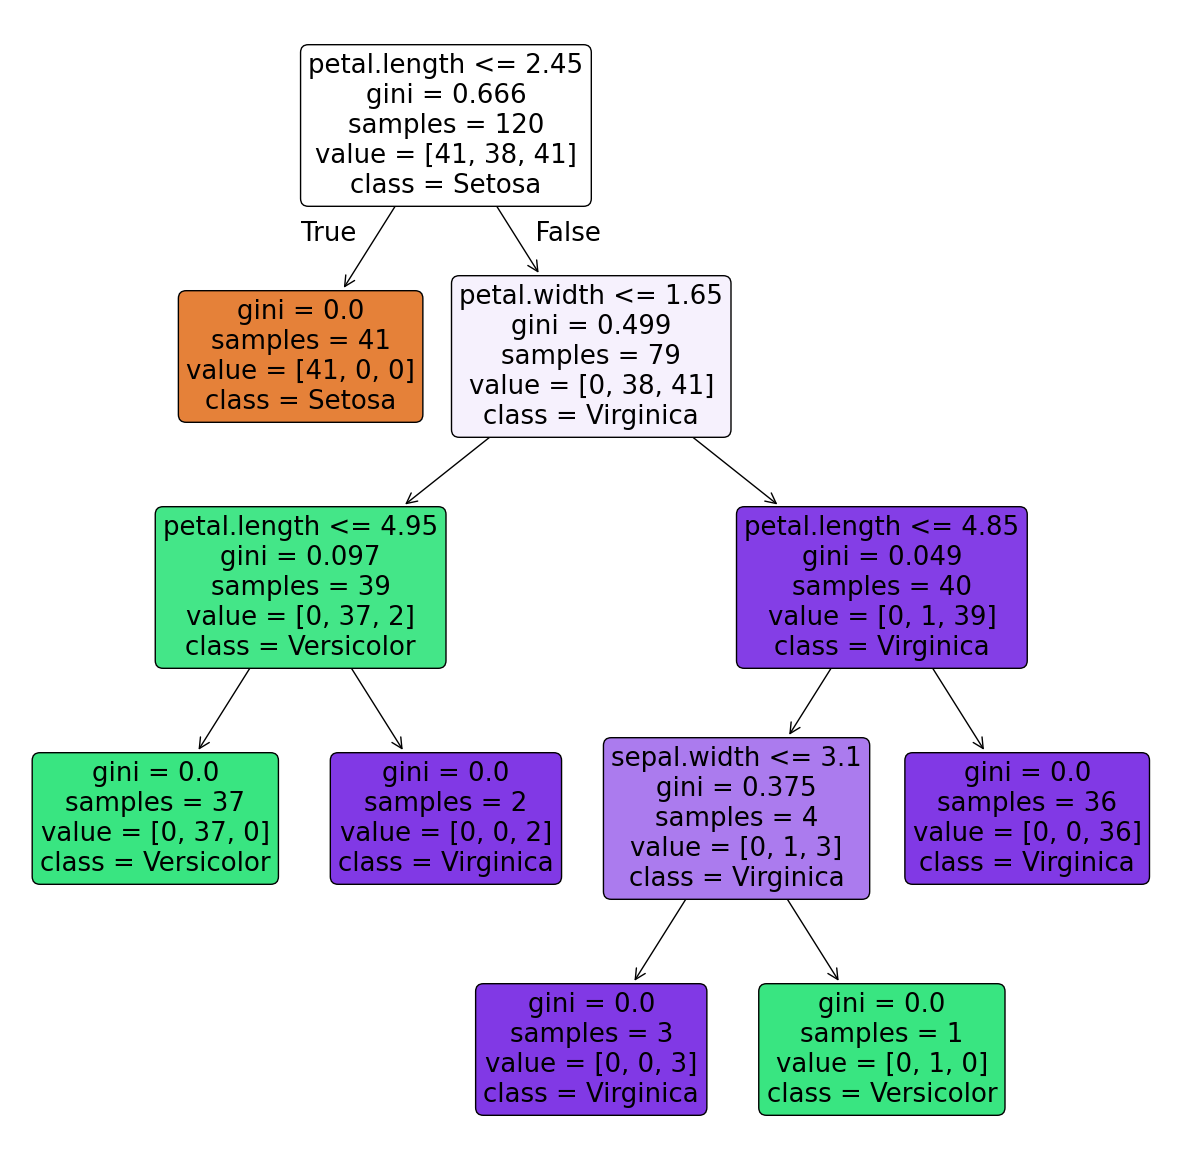

In [ ]:
plt.figure(figsize=(15,15))
plot_tree(iris_cf, feature_names=iris_df.columns,
          class_names=iris_cf.classes_,
          filled=True, rounded=True)
plt.show()

* ทดสอบการ predict (classify) ด้วย testing data
```python
<classifier>.predict(<target>)
```

In [ ]:
y_predict = iris_cf.predict(X_test)
y_predict

array(['Versicolor', 'Virginica', 'Virginica', 'Virginica', 'Virginica',
       'Versicolor', 'Versicolor', 'Virginica', 'Virginica', 'Versicolor',
       'Setosa', 'Versicolor', 'Setosa', 'Versicolor', 'Versicolor',
       'Versicolor', 'Versicolor', 'Setosa', 'Setosa', 'Setosa',
       'Virginica', 'Virginica', 'Setosa', 'Versicolor', 'Virginica',
       'Virginica', 'Virginica', 'Setosa', 'Setosa', 'Setosa'],
      dtype=object)

## 1.5 วัดประสิทธิภาพของโมเดลที่ได้


* ใช้ confusion_matrix และ classification_report จาก library sklearn.metrics
```python
from sklearn.metrics import confusion_matrix, classification_report
```

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

* confution matrix
```python
confusion_matrix(<true label>, <predicted label>)
```

In [ ]:
confusion_matrix(y_test, y_predict)

array([[ 9,  0,  0],
       [ 0, 10,  2],
       [ 0,  0,  9]])

In [ ]:
pd.DataFrame(confusion_matrix(y_test, y_predict), columns=iris_cf.classes_, index=iris_cf.classes_)

,Setosa,Versicolor,Virginica
Setosa,9,0,0
Versicolor,0,10,2
Virginica,0,0,9


* classification_report
```python
print(classification_report(<true label>, <predicted label>))
```

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         9
  Versicolor       1.00      0.83      0.91        12
   Virginica       0.82      1.00      0.90         9

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.95      0.93      0.93        30



## 1.6 ใช้ Decirion Tree ในการทำนาย

* สร้าง DataFrame iris_unknown

In [ ]:
iris_unknown = pd.DataFrame([[5.2,2.7,3.9,1.4],
                             [3.2,3.7,4.9,3.4]],
                             columns=iris_df.columns[:-1])

* Prediction

In [ ]:
iris_cf.predict(iris_unknown)

array(['Versicolor', 'Virginica'], dtype=object)